# Spatial sequences: graph convolution + LSTM

Represent geographic cells as nodes with daily sequences. Copy each code block into a new Colab cell in order. Common preparation uses exactly the data, normalization, targets and splits of the map tutorial. We make message passing visible and preserve one probability per cell. This is an exploratory teaching adaptation of the Keras graph-and-LSTM example.

## Start with a blank Colab notebook

Open [a new Colab notebook](https://colab.research.google.com/#create=true), select a Python CPU runtime, and copy each numbered Python block into its own code cell, in order. The **Copy** button copies code only. Keep this page alongside Colab for the explanations. You can instead download the matching notebook above and run its existing cells.

The first run downloads a **frozen public data pack** automatically. Its URL is pinned to a Git commit and its SHA-256 is checked. There is no manual ZIP upload and no live catalogue query. After an interrupted session, run the notebook again from the beginning. Outputs below labelled *prepared local run* come from an independent local CPU execution; they are not a claim about your Colab session.

Colab normally supplies the required libraries. If imports fail, install `tensorflow==2.19.1 pandas scikit-learn matplotlib` in a separate cell with `%pip install`, restart the runtime, and begin again. Exact local versions and timings are recorded with the prepared results. Installation changes the active Colab environment only.

## Prepare the environment

We use small networks and three predeclared seeds. Seeds describe variability in optimization, not uncertainty from new earthquakes. The tutorials evaluate **validation only**: the existing course test period has already been inspected. Changing architecture now does not make that period an untouched test again.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_NUM_INTRAOP_THREADS"] = "2"
os.environ["TF_NUM_INTEROP_THREADS"] = "2"

from pathlib import Path
import datetime, hashlib, json, platform, time, uuid, zipfile
from urllib.request import urlopen
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import tensorflow as tf
from tensorflow import keras
from IPython.display import display

try:
    tf.config.threading.set_intra_op_parallelism_threads(2)
    tf.config.threading.set_inter_op_parallelism_threads(2)
except RuntimeError:
    print("Thread settings were already initialized; restart for the reference settings.")

SEEDS = [7, 17, 27]
EPOCHS, BATCH_SIZE = 20, 64
TUTORIAL = "graphs"
RUN_DIR = Path("tutorial-runs") / (TUTORIAL + "-" + uuid.uuid4().hex[:12])
RUN_DIR.mkdir(parents=True, exist_ok=False)
started_at = time.perf_counter()
print("Python:", platform.python_version(), "TensorFlow:", tf.__version__, "Keras:", keras.__version__)
print("Validation only. Results will be saved to", RUN_DIR)

Python: 3.12.14 TensorFlow: 2.19.1 Keras: 3.15.1
Validation only. Results will be saved to tutorial-runs\graphs-7f8639c197f2


## Download and verify the frozen catalogue

The pack contains the regional USGS catalogue and its provenance. It includes records down to M 3 for diagnostics; these tutorials retain **M ≥ 4.5 as inputs** and **M ≥ 5 as targets**. Magnitudes are the preferred catalogue values, not a claim that all measurements use the same magnitude scale.

The catalogue was downloaded in October 2026 and contains revised records. Separating inputs and targets by event time cannot reconstruct which catalogue versions were available historically. These are retrospective teaching experiments, not operational forecasts or maps of shaking or risk.

In [2]:
PACK_URL = "https://raw.githubusercontent.com/FranPlaza/FranPlaza.github.io/0e7a7e4b1c38490018f11b26170fe6a87e4997f9/courses/statsei14/downloads/data-pack.zip"
PACK_SHA256 = "0ee5d4d71aafa19023fdb1ee6f289a11e7fd7f4ed88ad7a91032ca24505d10a2"
CATALOGUE_SHA256 = "16e9b731a5b407d75a2321d3d0d2c889542e8223a9ee4fe81efe624eb6b166d2"
archive_path = Path("statsei14-data-pack.zip")
if not archive_path.exists():
    with urlopen(PACK_URL, timeout=60) as response:
        payload = response.read()
    assert hashlib.sha256(payload).hexdigest() == PACK_SHA256, "Unexpected download: stop."
    archive_path.write_bytes(payload)
assert hashlib.sha256(archive_path.read_bytes()).hexdigest() == PACK_SHA256, "Changed cached pack: stop."
DATA_DIR = Path("statsei14-data").resolve()
DATA_DIR.mkdir(exist_ok=True)
with zipfile.ZipFile(archive_path) as archive:
    for member in archive.infolist():
        assert (DATA_DIR / member.filename).resolve().is_relative_to(DATA_DIR), "Unsafe ZIP member."
    archive.extractall(DATA_DIR)
catalogue_path = DATA_DIR / "data/frozen/usgs_chile_2000_2025.csv"
assert hashlib.sha256(catalogue_path.read_bytes()).hexdigest() == CATALOGUE_SHA256
events = pd.read_csv(catalogue_path)
events["time"] = pd.to_datetime(events["time"], utc=True)
events = events.sort_values("time").reset_index(drop=True)
print("Verified catalogue records:", len(events))
display(events[["time", "latitude", "longitude", "mag"]].head())

Verified catalogue records:

 12859


,time,latitude,longitude,mag
0,2000-01-07 11:49:11.720000+00:00,-28.495,-69.196,4.0
1,2000-01-08 11:43:58.150000+00:00,-31.017,-71.339,4.4
2,2000-01-11 13:16:34.420000+00:00,-30.747,-71.319,4.5
3,2000-01-18 17:12:18.360000+00:00,-31.630,-71.451,4.9
4,2000-01-19 01:24:00.150000+00:00,-31.440,-71.384,3.8


## Turn events into daily inputs

Each day has three channels: `log(1 + count)`, maximum magnitude above 4.5 (zero on an empty day), and an event-presence indicator. The regional series pools all locations. For the spatial tutorials we also keep six fixed geographic cells: three latitude bands by two longitude bands. Cell IDs run west to east within each row, then south to north. They are illustrative geographic bins, not inferred tectonic provinces; degree-based cells do not have identical physical areas. We retain the same domain and magnitude thresholds for every model.

Only **training data** should be used to judge whether the grid has adequate support. A finer map would create more rare targets, not automatically more useful information. In Tutorial 1, `X_regional` is the input; the spatial arrays are prepared here so the three tutorials share one transparent data pipeline.

In [3]:
START = pd.Timestamp("2000-01-01", tz="UTC")
END = pd.Timestamp("2026-01-01", tz="UTC")  # exclusive
days = pd.date_range(START, END - pd.Timedelta(days=1), freq="D")
LAT_EDGES = np.array([-34.0, -32.0, -30.0, -28.0])
LON_EDGES = np.array([-74.0, -71.5, -69.0])
N_ROWS, N_COLS = 3, 2
FEATURES = ["log_count", "max_magnitude_excess", "has_event"]
inside = events.latitude.between(LAT_EDGES[0], LAT_EDGES[-1]) & events.longitude.between(LON_EDGES[0], LON_EDGES[-1])
selected = events.loc[inside & (events.time >= START) & (events.time < END) & (events.mag >= 4.5)].copy()
selected["day"] = (selected.time.dt.floor("D") - START).dt.days
selected["row"] = np.clip(np.searchsorted(LAT_EDGES, selected.latitude, side="right") - 1, 0, N_ROWS - 1)
selected["col"] = np.clip(np.searchsorted(LON_EDGES, selected.longitude, side="right") - 1, 0, N_COLS - 1)

counts = np.zeros((len(days), N_ROWS, N_COLS), dtype=np.float32)
max_excess = np.zeros_like(counts)
target_counts = np.zeros_like(counts)
indices = (selected.day.to_numpy(), selected.row.to_numpy(), selected.col.to_numpy())
np.add.at(counts, indices, 1)
np.maximum.at(max_excess, indices, selected.mag.to_numpy() - 4.5)
qualifying = selected.mag.to_numpy() >= 5.0
np.add.at(target_counts, tuple(axis[qualifying] for axis in indices), 1)
daily_grid_raw = np.stack([np.log1p(counts), max_excess, (counts > 0).astype(float)], axis=-1).astype("float32")
daily_regional_raw = np.stack([
    np.log1p(counts.sum(axis=(1, 2))),
    max_excess.max(axis=(1, 2)),
    (counts.sum(axis=(1, 2)) > 0).astype(float)
], axis=-1).astype("float32")
assert int(counts.sum()) == len(selected)
assert int(target_counts.sum()) == int(qualifying.sum())
print("Daily regional:", daily_regional_raw.shape, "; daily grid:", daily_grid_raw.shape)

Daily regional: (9497, 3) ; daily grid: (9497, 3, 2, 3)


## Build histories, labels and chronological partitions

At each Monday origin `t`, inputs use `[t − 30 days, t)` and targets use `[t, t + 7 days)`. We remove any target interval that crosses a train/validation/test boundary or the end of the catalogue. Inputs to a later partition can contain earlier historical days; their outcomes never enter training. Weekly target windows do not overlap, although histories overlap and earthquake sequences remain dependent.

The regional target is one binary outcome. The spatial target has six binary outcomes: several cells may be positive in the same week, or all may be zero. Six cell probabilities therefore need not sum to one.

In [4]:
LOOKBACK, HORIZON = 30, 7
VAL_START = pd.Timestamp("2017-01-01", tz="UTC")
TEST_START = pd.Timestamp("2021-01-01", tz="UTC")
regional_windows, grid_windows, grid_labels, kept_origins, partitions = [], [], [], [], []
excluded = []
for origin in pd.date_range("2001-01-01", "2025-12-31", freq="W-MON", tz="UTC"):
    i = (origin - START).days
    stop = origin + pd.Timedelta(days=HORIZON)
    split = "train" if origin < VAL_START else ("validation" if origin < TEST_START else "test")
    boundary = VAL_START if split == "train" else (TEST_START if split == "validation" else END)
    if i < LOOKBACK or stop > boundary:
        excluded.append(str(origin.date()))
        continue
    regional_windows.append(daily_regional_raw[i - LOOKBACK:i])
    grid_windows.append(daily_grid_raw[i - LOOKBACK:i])
    grid_labels.append((target_counts[i:i + HORIZON].sum(axis=0) > 0).astype("int32"))
    kept_origins.append(origin)
    partitions.append(split)
origins = pd.DatetimeIndex(kept_origins)
partitions = np.asarray(partitions)
raw_regional = np.stack(regional_windows)
raw_grid = np.stack(grid_windows)
y_grid = np.stack(grid_labels)
y_regional = y_grid.any(axis=(1, 2)).astype("int32")
train_mask = partitions == "train"
val_mask = partitions == "validation"
test_mask = partitions == "test"
assert np.all(origins[train_mask] + pd.Timedelta(days=HORIZON) <= VAL_START)
assert np.all(origins[val_mask] + pd.Timedelta(days=HORIZON) <= TEST_START)
assert np.all(origins[test_mask] + pd.Timedelta(days=HORIZON) <= END)
assert not np.any(train_mask & val_mask)
print("Windows:", dict(zip(*np.unique(partitions, return_counts=True))))
print("Excluded boundary/incomplete targets:", excluded)
display(pd.DataFrame({
    "cell": np.arange(N_ROWS * N_COLS),
    "row_south_to_north": np.repeat(np.arange(N_ROWS), N_COLS),
    "col_west_to_east": np.tile(np.arange(N_COLS), N_ROWS),
    "training_positive_weeks": y_grid[train_mask].sum(axis=0).reshape(-1),
    "training_base_rate": y_grid[train_mask].mean(axis=0).reshape(-1)
}))

Windows: {np.str_('test'): np.int64(260), np.str_('train'): np.int64(834), np.str_('validation'): np.int64(208)}
Excluded boundary/incomplete targets: ['2016-12-26', '2020-12-28', '2025-12-29']


,cell,row_south_to_north,col_west_to_east,training_positive_weeks,training_base_rate
0,0,0,0,57,0.068345
1,1,0,1,26,0.031175
2,2,1,0,49,0.058753
3,3,1,1,37,0.044365
4,4,2,0,19,0.022782
5,5,2,1,41,0.049161


## Standardize using training histories only

For regional inputs, we estimate one mean and standard deviation per channel. For spatial inputs, we also use one pair per channel, pooled across training cells, so the map and graph models receive exactly the same scaled arrays. Empty days remain distinguishable through the presence channel. Target labels are never standardized.

The metric function averages squared probability errors and binary log losses. On spatial outputs these are averages of **marginal cell scores**, not the likelihood of a joint spatial point process. We will also inspect each cell separately.

In [5]:
regional_mean = raw_regional[train_mask].mean(axis=(0, 1), dtype=np.float64)
regional_scale = raw_regional[train_mask].std(axis=(0, 1), dtype=np.float64)
regional_scale = np.where(regional_scale > 0, regional_scale, 1.0)
grid_mean = raw_grid[train_mask].mean(axis=(0, 1, 2, 3), dtype=np.float64)
grid_scale = raw_grid[train_mask].std(axis=(0, 1, 2, 3), dtype=np.float64)
grid_scale = np.where(grid_scale > 0, grid_scale, 1.0)
X_regional = ((raw_regional - regional_mean) / regional_scale).astype("float32")
X_grid = ((raw_grid - grid_mean) / grid_scale).astype("float32")
assert X_regional.shape[1:] == (30, 3) and X_grid.shape[1:] == (30, 3, 2, 3)
assert np.isfinite(X_regional).all() and np.isfinite(X_grid).all()

def score_probabilities(y_true, probability):
    y_true = np.asarray(y_true, dtype=float)
    probability = np.asarray(probability, dtype=float)
    assert y_true.shape == probability.shape
    assert np.isin(y_true, [0, 1]).all() and np.isfinite(probability).all()
    assert ((probability >= 0) & (probability <= 1)).all()
    clipped = np.clip(probability, 1e-7, 1 - 1e-7)
    return {"brier": float(np.mean((probability - y_true) ** 2)),
            "log_loss": float(-np.mean(y_true * np.log(clipped) + (1 - y_true) * np.log1p(-clipped)))}

protocol = {
    "tutorial": TUTORIAL, "seeds": SEEDS, "epochs_max": EPOCHS, "batch_size": BATCH_SIZE,
    "lookback_days": LOOKBACK, "horizon_days": HORIZON,
    "pack_url": PACK_URL, "pack_sha256": PACK_SHA256, "catalogue_sha256": CATALOGUE_SHA256,
    "features": FEATURES, "latitude_edges": LAT_EDGES.tolist(), "longitude_edges": LON_EDGES.tolist(),
    "train": "2001-2016", "validation": "2017-2020", "test": "2021-2025; not evaluated here",
    "historical_as_of_verified": False, "scope": "Exploratory retrospective; validation only",
    "regional_mean": regional_mean.tolist(), "regional_scale": regional_scale.tolist(),
    "grid_mean": grid_mean.tolist(), "grid_scale": grid_scale.tolist(),
    "python": platform.python_version(), "tensorflow": tf.__version__, "keras": keras.__version__,
    "numpy": np.__version__, "pandas": pd.__version__, "scikit_learn": sklearn.__version__
}
(RUN_DIR / "protocol.json").write_text(json.dumps(protocol, indent=2), encoding="utf-8")
pd.DataFrame({"origin": origins.astype(str), "split": partitions}).to_csv(RUN_DIR / "windows.csv", index=False)
print("Ready:", X_regional.shape, X_grid.shape, "; no test outcomes used for fitting or evaluation.")

Ready: (1302, 30, 3) (1302, 30, 3, 2, 3) ; no test outcomes used for fitting or evaluation.


## 1. Change representation, retain the support

A node is **the same geographic cell** used in the map tutorial. We have six nodes, not six individual earthquakes. Each node carries the same three daily features for 30 days and predicts its own seven-day M >= 5 indicator.

```text
(batch, 30 days, 3 rows, 2 columns, 3 features)
      reshape only; no averaging
(batch, 30 days, 6 nodes, 3 features)
      graph convolution within each day
(batch, 30 days, 6 nodes, 8 learned features)
      shared LSTM applied to each node sequence
(batch, 6 nodes, 16 hidden features)
      shared sigmoid head: six probabilities
```

Identical cells, features, targets and chronology make the comparison interpretable. Graphs can also support irregular zones, but changing zones now would confound architecture with aggregation. Geographic rectangles are unequal in area and do not define physical interaction regions. Inspect training support before fitting.


In [6]:
# Common preparation has defined the standardized grid, targets and splits.
N_NODES = N_ROWS * N_COLS
assert X_grid.shape[1:] == (30, N_ROWS, N_COLS, len(FEATURES))
assert y_grid.shape == (len(X_grid), N_ROWS, N_COLS)
assert np.isfinite(X_grid).all() and np.isin(y_grid, [0, 1]).all()
assert not np.any(train_mask & val_mask)
assert not np.any(train_mask & test_mask)
assert not np.any(val_mask & test_mask)
assert train_mask.sum() > 0 and val_mask.sum() > 0
OUTPUT_DIR = RUN_DIR / 'graphs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
Y = y_grid.reshape(len(y_grid), N_NODES).astype('float32')
y_train, y_val = Y[train_mask], Y[val_mask]
validation_origins = pd.DatetimeIndex(origins[val_mask])
lat_centres = (np.asarray(LAT_EDGES[:-1]) + np.asarray(LAT_EDGES[1:])) / 2
lon_centres = (np.asarray(LON_EDGES[:-1]) + np.asarray(LON_EDGES[1:])) / 2
node_table = pd.DataFrame([
    {'node': r * N_COLS + c, 'row': r, 'column': c,
     'latitude': lat_centres[r], 'longitude': lon_centres[c],
     'training_windows': len(y_train),
     'training_positive_windows': int(y_train[:, r * N_COLS + c].sum()),
     'training_prevalence': float(y_train[:, r * N_COLS + c].mean())}
    for r in range(N_ROWS) for c in range(N_COLS)
])
node_table.to_csv(OUTPUT_DIR / 'spatial_support.csv', index=False)
display(node_table)
print('Input:', X_grid.shape, '| target:', y_grid.shape)
print('Counts describe positive forecast windows, not independent earthquakes.')
if (node_table.training_positive_windows < 20).any():
    print('Sparse cells: fitting and calibration can be unstable.')

X_nodes = X_grid.reshape(len(X_grid), 30, N_NODES, len(FEATURES))
assert np.array_equal(X_nodes[:, :, 0, :], X_grid[:, :, 0, 0, :])
assert np.array_equal(Y[:, 0], y_grid[:, 0, 0])
print('Node sequence shape:', X_nodes.shape)


,node,row,column,latitude,longitude,training_windows,training_positive_windows,training_prevalence
0,0,0,0,-33.0,-72.75,834,57,0.068345
1,1,0,1,-33.0,-70.25,834,26,0.031175
2,2,1,0,-31.0,-72.75,834,49,0.058753
3,3,1,1,-31.0,-70.25,834,37,0.044365
4,4,2,0,-29.0,-72.75,834,19,0.022782
5,5,2,1,-29.0,-70.25,834,41,0.049161


Input: (1302, 30, 3, 2, 3) | target: (1302, 3, 2)
Counts describe positive forecast windows, not independent earthquakes.
Sparse cells: fitting and calibration can be unstable.
Node sequence shape: (1302, 30, 6, 3)


## 2. Declare a graph without looking at outcomes

Connect cells sharing an edge (**rook adjacency**), without diagonals. Add a self-loop and divide each row by its degree. Matrix multiplication then computes a mean over a node and its immediate neighbours. Undirected connectivity is symmetric; normalized weights can be asymmetric because node degrees differ.

These geometric edges do not establish earthquake triggering, wave propagation or a measured distance relationship. Boundaries omit neighbours outside the region. Create the graph without validation or test labels.


,0,1,2,3,4,5
0,0.333333,0.333333,0.333333,0.000000,0.000000,0.000000
1,0.333333,0.333333,0.000000,0.333333,0.000000,0.000000
2,0.250000,0.000000,0.250000,0.250000,0.250000,0.000000
3,0.000000,0.250000,0.250000,0.250000,0.000000,0.250000
4,0.000000,0.000000,0.333333,0.000000,0.333333,0.333333
5,0.000000,0.000000,0.000000,0.333333,0.333333,0.333333


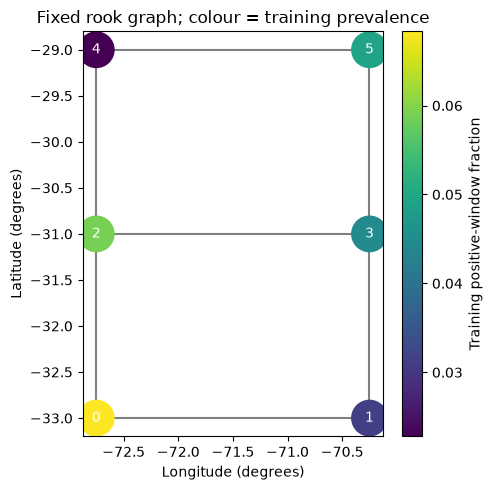

In [7]:
A = np.zeros((N_NODES, N_NODES), dtype='float32')
for r in range(N_ROWS):
    for c in range(N_COLS):
        source = r * N_COLS + c
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            rr, cc = r + dr, c + dc
            if 0 <= rr < N_ROWS and 0 <= cc < N_COLS:
                A[source, rr * N_COLS + cc] = 1
A_with_self = A + np.eye(N_NODES, dtype='float32')
A_normalized = A_with_self / A_with_self.sum(axis=1, keepdims=True)
assert np.array_equal(A, A.T)
assert np.allclose(A_normalized.sum(axis=1), 1)
np.save(OUTPUT_DIR / 'adjacency_normalized.npy', A_normalized)
display(pd.DataFrame(A_normalized, index=range(N_NODES), columns=range(N_NODES)))
fig, ax = plt.subplots(figsize=(5, 5))
for i, j in zip(*np.where(np.triu(A, k=1))):
    ax.plot(node_table.loc[[i, j], 'longitude'], node_table.loc[[i, j], 'latitude'],
            color='grey', zorder=1)
scatter = ax.scatter(node_table.longitude, node_table.latitude,
                     c=node_table.training_prevalence, s=650, cmap='viridis', zorder=2)
for row in node_table.itertuples():
    ax.text(row.longitude, row.latitude, str(row.node), ha='center', va='center', color='white')
ax.set(xlabel='Longitude (degrees)', ylabel='Latitude (degrees)',
       title='Fixed rook graph; colour = training prevalence')
fig.colorbar(scatter, ax=ax, label='Training positive-window fraction')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'graph_support.png', dpi=160)
plt.show()


## 3. Make message passing visible

For each day and node, compute `relu(W_self x + W_neighbour mean_neighbours(x) + bias)`. The mean includes the node itself; the direct self transformation separately retains its original features. The transformations are learned, while adjacency stays fixed.

The [Keras graph-and-LSTM traffic example](https://keras.io/examples/timeseries/timeseries_traffic_forecasting/) motivates combining spatial messages and temporal recurrence. We implement a small dense-adjacency layer for six cells and binary catalogue-event probabilities. This adapts the mechanism; it does not reproduce the example's data, graph rule or performance.

**Check:** Is node 3 an immediate neighbour of node 0? Can one graph layer send a message across two edges?


In [8]:
@keras.utils.register_keras_serializable(package='STATSEI14')
class GraphConv(keras.layers.Layer):
    def __init__(self, units, adjacency, **kwargs):
        super().__init__(**kwargs)
        self.units = int(units)
        self.adjacency_list = np.asarray(adjacency, dtype='float32').tolist()
        self.self_projection = keras.layers.Dense(self.units, use_bias=True)
        self.neighbour_projection = keras.layers.Dense(self.units, use_bias=False)

    def build(self, input_shape):
        n_nodes = len(self.adjacency_list)
        if input_shape[-2] != n_nodes:
            raise ValueError('Node axis must match the adjacency matrix.')
        self.adjacency = self.add_weight(
            name='fixed_adjacency', shape=(n_nodes, n_nodes),
            initializer=keras.initializers.Constant(self.adjacency_list), trainable=False,
        )
        self.self_projection.build(input_shape)
        self.neighbour_projection.build(input_shape)
        super().build(input_shape)

    def call(self, inputs):
        # i receives, j sends; b = batch, t = time, f = feature.
        neighbours = keras.ops.einsum('ij,btjf->btif', self.adjacency, inputs)
        return keras.ops.relu(
            self.self_projection(inputs) + self.neighbour_projection(neighbours)
        )

    def get_config(self):
        return {**super().get_config(), 'units': self.units,
                'adjacency': self.adjacency_list}


## 4. Preserve each node's temporal trajectory

After graph convolution, permute `(time, node, feature)` into `(node, time, feature)`. `TimeDistributed(LSTM)` now iterates over **nodes**, applying one shared temporal model to their daily sequences. No global pooling is applied; every output stays tied to its own cell.

The shared head has no free cell-specific intercept. Different predictions come from local and neighbouring histories. This restriction can make persistent cell-specific prevalence difficult to reproduce, which makes the baseline essential. Six sigmoid outputs need not sum to one and do not establish independent seismic processes.


In [9]:
def build_graph_lstm(adjacency):
    inputs = keras.Input(shape=X_nodes.shape[1:], name='node_sequences')
    x = GraphConv(8, adjacency, name='spatial_messages')(inputs)
    x = keras.layers.Permute((2, 1, 3), name='one_sequence_per_node')(x)
    x = keras.layers.TimeDistributed(
        keras.layers.LSTM(16), name='shared_node_memory',
    )(x)
    x = keras.layers.TimeDistributed(
        keras.layers.Dense(1, activation='sigmoid'), name='shared_probability_head',
    )(x)
    outputs = keras.layers.Reshape((N_NODES,), name='node_probabilities')(x)
    model = keras.Model(inputs, outputs, name='graph_lstm')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss=keras.losses.BinaryCrossentropy())
    return model

keras.utils.set_random_seed(SEEDS[0])
preview_model = build_graph_lstm(A_normalized)
preview_model.summary()
assert preview_model(X_nodes[train_mask][:2], training=False).shape == (2, N_NODES)
# Ensure the custom layer's configuration and weights survive cloning.
cloned = keras.models.clone_model(preview_model)
cloned.set_weights(preview_model.get_weights())
np.testing.assert_allclose(
    preview_model(X_nodes[train_mask][:2], training=False).numpy(),
    cloned(X_nodes[train_mask][:2], training=False).numpy(), rtol=1e-5, atol=1e-6,
)
print('Custom layer clone check passed.')


Model: "graph_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ node_sequences (InputLayer)     │ (None, 30, 6, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_messages (GraphConv)    │ (None, 30, 6, 8)       │            92 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ one_sequence_per_node (Permute) │ (None, 6, 30, 8)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_node_memory              │ (None, 6, 16)          │         1,600 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_probability_head         │ (None, 6, 1)           │            17 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ node_probabilities (Reshape)    │ (None, 6)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,709 (6.68 KB)

 Trainable params: 1,673 (6.54 KB)

 Non-trainable params: 36 (144.00 B)

Custom layer clone check passed.


## 5. Keep the same spatial baseline and scoring

Repeat each cell's training prevalence for every validation origin. Keep row-major ordering in both targets and predictions; a shape check alone would not detect a permutation that pairs probabilities with another cell's outcomes.

Brier score measures squared probability errors. Log loss penalizes confident errors strongly; the shared scorer clips probabilities for numerical stability. Report pooled scores and all six cell scores, including cells without observed positives.


In [10]:
metric_rows, zone_metric_rows, prediction_tables = [], [], []
validation_predictions = {}

def record_validation(name, seed, probabilities, parameters, fit_seconds,
                      predict_seconds, epochs_run, best_epoch):
    probabilities = np.asarray(probabilities).reshape(len(y_val), N_NODES)
    assert np.isfinite(probabilities).all()
    assert ((0 <= probabilities) & (probabilities <= 1)).all()
    scores = score_probabilities(y_val.ravel(), probabilities.ravel())
    metric_rows.append(dict(model=name, seed=seed, split='validation',
                            parameters=parameters, fit_seconds=fit_seconds,
                            predict_seconds=predict_seconds, epochs_run=epochs_run,
                            best_epoch=best_epoch, **scores))
    for node in range(N_NODES):
        zone_metric_rows.append(dict(
            model=name, seed=seed, split='validation', node=node,
            n_windows=len(y_val), positives=int(y_val[:, node].sum()),
            **score_probabilities(y_val[:, node], probabilities[:, node])))
    prediction_tables.append(pd.DataFrame({
        'origin': np.repeat(validation_origins.astype(str).to_numpy(), N_NODES),
        'node': np.tile(np.arange(N_NODES), len(y_val)),
        'observed': y_val.astype(int).ravel(), 'probability': probabilities.ravel(),
        'model': name, 'seed': seed, 'split': 'validation',
    }))
    validation_predictions[(name, seed)] = probabilities.copy()

prevalence = y_train.mean(axis=0)
p_baseline = np.broadcast_to(prevalence, y_val.shape).copy()
record_validation('Cell prevalence', -1, p_baseline, 0, 0.0, 0.0, 0, 0)
print('Baseline validation scores:', metric_rows[-1])


Baseline validation scores: {'model': 'Cell prevalence', 'seed': -1, 'split': 'validation', 'parameters': 0, 'fit_seconds': 0.0, 'predict_seconds': 0.0, 'epochs_run': 0, 'best_epoch': 0, 'brier': 0.045091246675882525, 'log_loss': 0.19124590620332385}


## 6. Fit three seeds with a fixed graph

Start each run from new weights and a fresh early-stopping callback. Graph edges never depend on validation correlations. Record parameters, runtime and epochs. `count_params()` includes 36 fixed adjacency weights as non-trainable parameters; the model summary separates them from trainable weights.

Validation controls early stopping and is also reported, making these development diagnostics. This tutorial does not evaluate the previously inspected test interval. CPU runs can take several minutes, and device choice changes runtime and potentially numerical results.


In [11]:
for seed in SEEDS:
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)
    model = build_graph_lstm(A_normalized)
    callback = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True,
    )
    print(f'\nGraph + LSTM, seed={seed}, parameters={model.count_params()}')
    start = time.perf_counter()
    history = model.fit(
        X_nodes[train_mask], y_train,
        validation_data=(X_nodes[val_mask], y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=False,
        callbacks=[callback], verbose=2,
    )
    fit_seconds = time.perf_counter() - start
    start = time.perf_counter()
    probabilities = model.predict(X_nodes[val_mask], batch_size=BATCH_SIZE, verbose=0)
    predict_seconds = time.perf_counter() - start
    pd.DataFrame(history.history).to_csv(
        OUTPUT_DIR / f'graph_lstm_seed{seed}_history.csv', index=False,
    )
    record_validation(
        'Graph + LSTM', seed, probabilities, model.count_params(), fit_seconds,
        predict_seconds, len(history.history['loss']),
        1 + int(np.argmin(history.history['val_loss'])),
    )



Graph + LSTM, seed=7, parameters=1709
Epoch 1/20


14/14 - 3s - 199ms/step - loss: 0.6446 - val_loss: 0.6001


Epoch 2/20


14/14 - 0s - 14ms/step - loss: 0.5562 - val_loss: 0.4744


Epoch 3/20


...

14/14 - 0s - 14ms/step - loss: 0.1784 - val_loss: 0.1869


Epoch 17/20


14/14 - 0s - 14ms/step - loss: 0.1782 - val_loss: 0.1869


Epoch 18/20


14/14 - 0s - 14ms/step - loss: 0.1780 - val_loss: 0.1869


## 7. Compare with the baseline before ranking architectures

The graph states which signals should be shared. It may help, harm, or add no information. Compare cell prevalence first, then compare these tables with the map tutorial under the identical support and target. Parameter counts and computational budgets still differ.

Seed variability measures initialization sensitivity, not sampling uncertainty. Even stable results across seeds cannot establish generalization to another period or region.


In [12]:
metrics = pd.DataFrame(metric_rows)
zone_metrics = pd.DataFrame(zone_metric_rows)
predictions = pd.concat(prediction_tables, ignore_index=True)
metrics.to_csv(OUTPUT_DIR / 'validation_metrics_by_seed.csv', index=False)
zone_metrics.to_csv(OUTPUT_DIR / 'validation_metrics_by_cell.csv', index=False)
predictions.to_csv(OUTPUT_DIR / 'validation_predictions.csv', index=False)
summary = metrics.groupby('model').agg(
    runs=('seed', 'size'), parameters=('parameters', 'first'),
    brier_mean=('brier', 'mean'), brier_seed_sd=('brier', 'std'),
    log_loss_mean=('log_loss', 'mean'), log_loss_seed_sd=('log_loss', 'std'),
    fit_seconds_mean=('fit_seconds', 'mean'),
    predict_seconds_mean=('predict_seconds', 'mean'), epochs_mean=('epochs_run', 'mean'),
).reset_index()
summary.to_csv(OUTPUT_DIR / 'validation_summary.csv', index=False)
display(summary)
display(zone_metrics.groupby(['model', 'node']).agg(
    positive_windows=('positives', 'first'), brier=('brier', 'mean'),
    log_loss=('log_loss', 'mean'),
).reset_index())
print('Seed SD describes initialization variability; it is not a confidence interval.')


,model,runs,parameters,brier_mean,brier_seed_sd,log_loss_mean,log_loss_seed_sd,fit_seconds_mean,predict_seconds_mean,epochs_mean
0,Cell prevalence,1,0,0.045091,NaN,0.191246,NaN,0.000000,0.000000,0.0
1,Graph + LSTM,3,1709,0.044170,0.000193,0.186388,0.000842,6.224973,0.594155,18.0


,model,node,positive_windows,brier,log_loss
0,Cell prevalence,0,10,0.046176,0.196389
1,Cell prevalence,1,6,0.028019,0.130800
2,Cell prevalence,2,14,0.062851,0.247252
3,Cell prevalence,3,13,0.058923,0.237250
4,Cell prevalence,4,9,0.041817,0.185683
5,Cell prevalence,5,7,0.032762,0.150101
6,Graph + LSTM,0,10,0.042605,0.176800
7,Graph + LSTM,1,6,0.028575,0.136593
8,Graph + LSTM,2,14,0.063622,0.256183
9,Graph + LSTM,3,13,0.057710,0.233573


Seed SD describes initialization variability; it is not a confidence interval.


## 8. Map probabilities back to their cells

Row-major reshaping returns the node vector to the map without interpolation. All panels share a colour scale. These are positive-window frequencies and catalogue-event probabilities, not shaking, damage or seismic risk.

The seed mean is an ensemble diagnostic; the earlier summary averages individual-seed scores. Spatially similar means do not establish accurate predictions at individual origins.


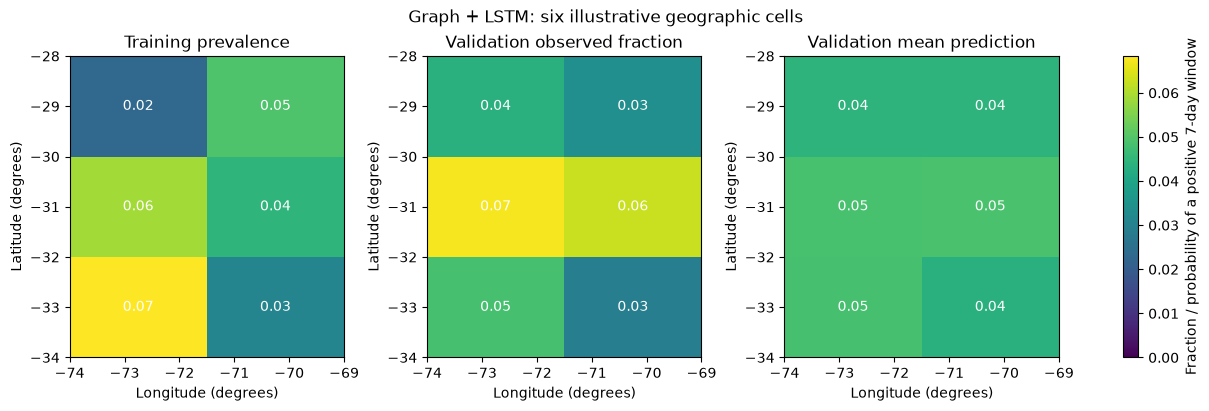

In [13]:
MAP_MODEL = 'Graph + LSTM'
mean_seed_prediction = np.mean([
    validation_predictions[(MAP_MODEL, seed)] for seed in SEEDS
], axis=0)
map_fields = [
    ('Training prevalence', prevalence.reshape(N_ROWS, N_COLS)),
    ('Validation observed fraction', y_val.mean(axis=0).reshape(N_ROWS, N_COLS)),
    ('Validation mean prediction', mean_seed_prediction.mean(axis=0).reshape(N_ROWS, N_COLS)),
]
vmax = max(float(field.max()) for _, field in map_fields)
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for ax, (title, field) in zip(axes, map_fields):
    mesh = ax.pcolormesh(LON_EDGES, LAT_EDGES, field, vmin=0, vmax=max(vmax, 0.01),
                         cmap='viridis', shading='flat')
    for node in range(N_NODES):
        r, c = divmod(node, N_COLS)
        ax.text(lon_centres[c], lat_centres[r], f'{field[r,c]:.2f}',
                ha='center', va='center', color='white')
    ax.set(title=title, xlabel='Longitude (degrees)', ylabel='Latitude (degrees)')
fig.colorbar(mesh, ax=axes, label='Fraction / probability of a positive 7-day window')
fig.suptitle(f'{MAP_MODEL}: six illustrative geographic cells')
fig.savefig(OUTPUT_DIR / 'validation_mean_maps.png', dpi=160)
plt.show()


## 9. Check calibration and sparse cells

Read the pooled curve alongside cell-specific frequencies. Dependence across cells and forecast origins prevents treating all origin-cell pairs as independent replicates. A sparse bin near the diagonal is still weak evidence; these flags are warnings, not pass/fail tests.

Pooling can hide overprediction in one cell and underprediction in another. Recalibrating and assessing on the same labels would not produce an independent performance estimate.


The calibration figure, pooled calibration table and cell-bias table below use the **mean prediction across the three predeclared seeds**. They describe that ensemble, whereas the preceding score summary averages separately scored runs.


,bin,n_origin_cell_pairs,positives,mean_probability,observed_fraction,sparse_warning
0,0,1242,57,0.044948,0.045894,False
1,1,6,2,0.291230,0.333333,True


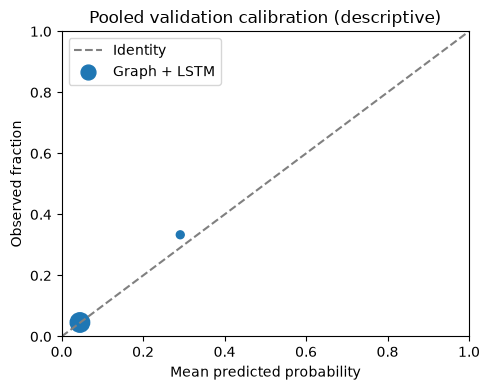

,node,latitude,longitude,validation_positive_windows,observed_fraction,mean_probability
0,0,-33.0,-72.75,10,0.048077,0.048195
1,1,-33.0,-70.25,6,0.028846,0.043311
2,2,-31.0,-72.75,14,0.067308,0.048424
3,3,-31.0,-70.25,13,0.062500,0.048633
4,4,-29.0,-72.75,9,0.043269,0.044117
5,5,-29.0,-70.25,7,0.033654,0.044113


In [14]:
bin_edges = np.linspace(0, 1, 6)
p_flat, y_flat = mean_seed_prediction.ravel(), y_val.ravel()
bin_index = np.minimum(np.searchsorted(bin_edges, p_flat, side='right') - 1, 4)
calibration_rows = []
for b in range(5):
    selected = bin_index == b
    if not selected.any():
        continue
    positives, n = int(y_flat[selected].sum()), int(selected.sum())
    calibration_rows.append({
        'bin': b, 'n_origin_cell_pairs': n, 'positives': positives,
        'mean_probability': float(p_flat[selected].mean()),
        'observed_fraction': float(y_flat[selected].mean()),
        'sparse_warning': n < 20 or positives < 5 or n - positives < 5,
    })
calibration = pd.DataFrame(calibration_rows)
calibration.to_csv(OUTPUT_DIR / 'validation_pooled_calibration.csv', index=False)
display(calibration)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot([0, 1], [0, 1], '--', color='grey', label='Identity')
ax.scatter(calibration.mean_probability, calibration.observed_fraction,
           s=20 + 5 * np.sqrt(calibration.n_origin_cell_pairs), label=MAP_MODEL)
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel='Mean predicted probability',
       ylabel='Observed fraction', title='Pooled validation calibration (descriptive)')
ax.legend(); fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'validation_calibration.png', dpi=160)
plt.show()
cell_bias = node_table[['node', 'latitude', 'longitude']].copy()
cell_bias['validation_positive_windows'] = y_val.sum(axis=0).astype(int)
cell_bias['observed_fraction'] = y_val.mean(axis=0)
cell_bias['mean_probability'] = mean_seed_prediction.mean(axis=0)
cell_bias.to_csv(OUTPUT_DIR / 'validation_cell_bias.csv', index=False)
display(cell_bias)


## 10. Design a control for the spatial claim

An **identity adjacency** prevents cross-node messages while preserving temporal histories, parameter counts, loss and training settings. In both the preview and training calls, use `build_graph_lstm(np.eye(N_NODES, dtype='float32'))`, keeping the direct self branch. This optional follow-up needs the same seeds and protocol, reported as another exploratory experiment rather than selected favourable runs.

**Exercises**

1. What remains learnable with identity adjacency? Does removing cross-node messages remove the LSTM?
2. Explain the rook edges and the physical interpretations that are unsupported.
3. Why would globally pooling all nodes before a single output change the scientific target?
4. Propose a future irregular-zone graph, declaring edges before inspecting outcomes. Inspect positive training support and reserve a new untouched interval.

Retain geometry, histories, predictions and the common data manifest. The Keras example supports an implementation pattern rather than a claim of validated seismic performance. Historical-as-of catalogue availability and fresh-Colab execution remain separate checks.

The final cell also copies the common data protocol and chronological window manifest, then downloads a ZIP containing this experiment.


In [15]:
protocol = {
    'tutorial': 'graphs', 'purpose': 'exploratory teaching extension',
    'evaluation_split': 'validation', 'test_evaluated_in_this_tutorial': False,
    'target': 'at least one catalogue M >= 5 event in next 7 days, per cell',
    'node_order': 'row-major: latitude_row * N_COLS + longitude_column',
    'latitude_edges': np.asarray(LAT_EDGES).tolist(),
    'longitude_edges': np.asarray(LON_EDGES).tolist(),
    'features': list(FEATURES), 'seeds': list(SEEDS),
    'max_epochs': EPOCHS, 'batch_size': BATCH_SIZE,
    'early_stopping': {'monitor': 'val_loss', 'patience': 3, 'restore_best_weights': True},
    'normalization': 'shared per feature across cells, fitted on training only',
    'keras_version': keras.__version__, 'tensorflow_version': tf.__version__,
    'historical_as_of_verified': False, 'colab_clean_execution_verified': False,
    'caveats': ['validation also controls early stopping',
                'seeds are not independent data replications',
                'geographic cells have unequal areas and truncated boundaries',
                'catalogue events are not ground-motion or damage observations',
                'original test period was previously inspected'],
}
(OUTPUT_DIR / 'protocol.json').write_text(json.dumps(protocol, indent=2), encoding='utf-8')
print('Saved validation outputs to:', OUTPUT_DIR)

# Bundle both source-data provenance and tutorial-specific experiment outputs.
import shutil
shutil.copy2(RUN_DIR / 'protocol.json', OUTPUT_DIR / 'data_protocol.json')
shutil.copy2(RUN_DIR / 'windows.csv', OUTPUT_DIR / 'windows.csv')
archive_path = shutil.make_archive(str(OUTPUT_DIR) + '_outputs', 'zip', root_dir=OUTPUT_DIR)
print('Downloadable experiment archive:', archive_path)
try:
    from google.colab import files
    files.download(archive_path)
except ImportError:
    print('Outside Colab: copy the archive from the displayed local path.')


Saved validation outputs to: tutorial-runs\graphs-7f8639c197f2\graphs
Downloadable experiment archive: H:\Otros ordenadores\Mi PC\1_Proyectos\2026 - Statsei 14 -\statsei14-deep-learning\qa\tutorials-2026-10-07\executions\graphs-704492a7\tutorial-runs\graphs-7f8639c197f2\graphs_outputs.zip
Outside Colab: copy the archive from the displayed local path.


## References and next steps

- [Keras: Traffic forecasting using graph neural networks and LSTM](https://keras.io/examples/timeseries/timeseries_traffic_forecasting/)

[Return to the practical guide](https://franplaza.github.io/courses/statsei14/practical.html). These implementations adapt general Keras mechanisms to an exploratory teaching task; their documentation does not validate earthquake forecasting skill.